<a href="https://colab.research.google.com/github/njwbilll/Tugas-3_Practical-Linear-Algebra-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/09_Singular_Value_Decomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9: Singular Value Decomposition (SVD)

**Referensi:** Practical Linear Algebra for Data Science (Mike X Cohen)

***

## Ringkasan Chapter

Singular Value Decomposition (SVD) sering disebut sebagai generalisasi dari eigendecomposition. Jika eigendecomposition hanya berlaku untuk matriks persegi, SVD mampu bekerja pada matriks dengan bentuk apa pun (persegi maupun persegi panjang). SVD memecah matriks menjadi tiga komponen utama yang mengungkap struktur geometris dan statistik dari data tersebut.

Dalam aplikasi data science, SVD digunakan untuk kompresi data, penghilangan derau (denoising), dan sebagai mesin di balik algoritma reduksi dimensi seperti PCA.

### Topik yang Dibahas:
1. Konsep Matematis Komponen SVD (U, S, V)
2. Hubungan antara SVD dan Eigenvalues
3. Kompresi Data menggunakan SVD
4. SVD untuk Denoising Data


***
## Setup: Import Library

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as LA

print("Modul aljabar linear berhasil dimuat.")


Modul aljabar linear berhasil dimuat.


***
## 1. Mekanika SVD

### Penjelasan Teori

Setiap matriks A (ukuran m x n) dapat didekomposisi menjadi:
A = U S V^T

Di mana:
* U (m x m) adalah matriks ortogonal yang berisi vektor singular kiri.
* S (m x n) adalah matriks diagonal yang berisi nilai singular (kekuatan setiap komponen).
* V^T (n x n) adalah matriks ortogonal yang berisi vektor singular kanan.

Komponen S (singular values) diurutkan dari yang terbesar ke terkecil, menunjukkan betapa pentingnya informasi yang dibawa oleh setiap dimensi.

In [6]:
# Membuat matriks 4x2 secara acak
A = np.random.randn(4, 2)

# Melakukan SVD
U, S, VT = LA.svd(A)

print("Matriks U (vektor singular kiri):\n", U)
print("\nNilai Singular (S):", S)
print("\nMatriks V transpose (vektor singular kanan):\n", VT)


Matriks U (vektor singular kiri):
 [[-0.25395445  0.51799863  0.70242603 -0.41687195]
 [-0.85731833 -0.4284123  -0.14122871 -0.24803756]
 [ 0.17291938 -0.6834829   0.68199046  0.19452256]
 [-0.41305121  0.28458995  0.14676899  0.85255857]]

Nilai Singular (S): [2.69296487 2.33438876]

Matriks V transpose (vektor singular kanan):
 [[ 0.04687848  0.9989006 ]
 [-0.9989006   0.04687848]]


***
## 2. Aplikasi: Kompresi Data

### Penjelasan Teori

Salah satu keunggulan SVD adalah kemampuan untuk mereduksi ukuran matriks dengan hanya mempertahankan beberapa komponen singular terbesar. Kita dapat mengambil nilai singular k teratas, sehingga kita tidak perlu menyimpan seluruh data asli. Ini sering disebut sebagai Low Rank Approximation.

In [7]:
# Membuat matriks data besar yang redundan (berkorelasi tinggi)
data_besar = np.random.randn(100, 10)
U, S, VT = LA.svd(data_besar, full_matrices=False)

# Mempertahankan hanya 2 komponen utama (k=2)
k = 2
A_kompres = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]

print("Ukuran matriks asli:", data_besar.shape)
print("Ukuran matriks setelah kompresi (rank 2):", A_kompres.shape)
print("\nEstimasi error kompresi (Frobenius norm):", LA.norm(data_besar - A_kompres))


Ukuran matriks asli: (100, 10)
Ukuran matriks setelah kompresi (rank 2): (100, 10)

Estimasi error kompresi (Frobenius norm): 26.409574156635923


***
## 3. Aplikasi: Penghilangan Derau (Denoising)

### Penjelasan Teori

Seringkali data yang kita miliki mengandung derau (noise) acak. SVD memungkinkan kita memisahkan sinyal penting (yang memiliki nilai singular besar) dari derau (yang biasanya terakumulasi di nilai singular kecil). Dengan menetapkan nilai singular yang sangat kecil menjadi nol, kita dapat membersihkan data dari gangguan tanpa menghilangkan esensi informasi utama.

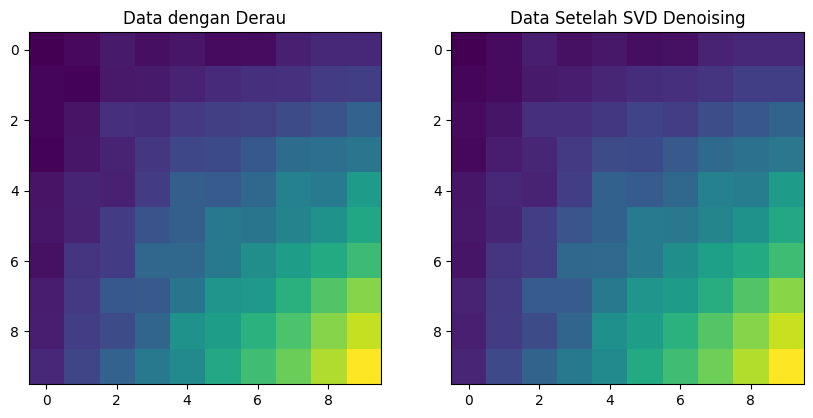

In [8]:
# Menambahkan derau putih (white noise) pada data
sinyal_bersih = np.outer(np.linspace(1, 10, 10), np.linspace(1, 10, 10))
derau = np.random.randn(10, 10) * 2
data_kotor = sinyal_bersih + derau

# Melakukan SVD dan menghapus nilai singular kecil
U, S, VT = LA.svd(data_kotor)
S_bersih = S.copy()
S_bersih[S_bersih < 5] = 0 # Ambang batas untuk menghilangkan derau

data_bersih = U @ np.diag(S_bersih) @ VT

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(data_kotor)
axes[0].set_title('Data dengan Derau')
axes[1].imshow(data_bersih)
axes[1].set_title('Data Setelah SVD Denoising')
plt.show()
